In [1]:
# ─────────────────────────────────────────────────────────────
# STEP 4 — FEATURE ENGINEERING
# ─────────────────────────────────────────────────────────────

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from pathlib import Path

print("=" * 60)
print("STEP 4 — FEATURE ENGINEERING")
print("=" * 60)

base = Path.cwd()

candidates = [
    base / "data" / "processed" / "application_train_cleaned.csv",
    Path(r"D:\home-credit-default-risk\data\processed\application_train_cleaned.csv"),
]

data_path = next((p for p in candidates if p.exists()), candidates[0])

df = pd.read_csv(data_path)

# Work on top of cleaned data
df_feat = df.copy()
starting_cols = df_feat.shape[1]
print(f"\n  Starting columns: {starting_cols}")

STEP 4 — FEATURE ENGINEERING

  Starting columns: 229


In [2]:
# ─────────────────────────────────────────────────────────────
# 4A. CREDIT BURDEN FEATURES
# WHY: How much debt is the applicant taking on relative
#      to their income and the goods they are buying?
#      High burden = higher default risk.
# ─────────────────────────────────────────────────────────────

print("\n[4A] CREDIT BURDEN FEATURES")
print("-" * 40)

# Credit-to-Income ratio
# Intuition: borrowing 10x your income is far riskier than 2x
df_feat["CREDIT_TO_INCOME_RATIO"] = (
    df_feat["AMT_CREDIT"] / (df_feat["AMT_INCOME_TOTAL"] + 1)
)

# Annuity-to-Income ratio
# Intuition: monthly repayment as share of income
# If annuity = 50% of income, very little left for living expenses
df_feat["ANNUITY_TO_INCOME_RATIO"] = (
    df_feat["AMT_ANNUITY"] / (df_feat["AMT_INCOME_TOTAL"] + 1)
)

# Credit-to-Goods ratio
# Intuition: how much extra credit beyond the goods price?
# Ratio > 1 means borrowing more than the goods are worth
df_feat["CREDIT_TO_GOODS_RATIO"] = (
    df_feat["AMT_CREDIT"] / (df_feat["AMT_GOODS_PRICE"] + 1)
)

# Annuity-to-Credit ratio
# Intuition: repayment speed — high ratio = shorter loan term
df_feat["ANNUITY_TO_CREDIT_RATIO"] = (
    df_feat["AMT_ANNUITY"] / (df_feat["AMT_CREDIT"] + 1)
)

# Income per family member
# Intuition: a family of 5 on the same income has less per person
df_feat["INCOME_PER_PERSON"] = (
    df_feat["AMT_INCOME_TOTAL"] / (df_feat["CNT_FAM_MEMBERS"] + 1)
)

print("  CREDIT_TO_INCOME_RATIO   — loan size vs annual income")
print("  ANNUITY_TO_INCOME_RATIO  — monthly payment vs income")
print("  CREDIT_TO_GOODS_RATIO    — borrowing vs asset value")
print("  ANNUITY_TO_CREDIT_RATIO  — repayment speed proxy")
print("  INCOME_PER_PERSON        — income adjusted for family size")


[4A] CREDIT BURDEN FEATURES
----------------------------------------
  CREDIT_TO_INCOME_RATIO   — loan size vs annual income
  ANNUITY_TO_INCOME_RATIO  — monthly payment vs income
  CREDIT_TO_GOODS_RATIO    — borrowing vs asset value
  ANNUITY_TO_CREDIT_RATIO  — repayment speed proxy
  INCOME_PER_PERSON        — income adjusted for family size


In [3]:
# ─────────────────────────────────────────────────────────────
# 4B. AGE & EMPLOYMENT FEATURES
# WHY: Older applicants and those with stable long employment
#      historically default less. These features capture
#      life-stage and employment stability signals.
# ─────────────────────────────────────────────────────────────

print("\n[4B] AGE & EMPLOYMENT FEATURES")
print("-" * 40)

# Employment-to-Age ratio
# Intuition: employed for 80% of adult life = very stable
df_feat["EMPLOYED_TO_AGE_RATIO"] = (
    df_feat["YEARS_EMPLOYED"] / (df_feat["AGE_YEARS"] + 1)
)

# Age at which they started working
# Intuition: started working early = financially experienced
df_feat["AGE_STARTED_WORKING"] = (
    df_feat["AGE_YEARS"] - df_feat["YEARS_EMPLOYED"]
)

# Age groups (binned)
# Intuition: young borrowers (20-30) default more than middle-aged
df_feat["AGE_GROUP"] = pd.cut(
    df_feat["AGE_YEARS"],
    bins  = [0, 27, 35, 45, 55, 100],
    labels= [0, 1, 2, 3, 4]           # ordinal encoding
).astype(float)

print("  EMPLOYED_TO_AGE_RATIO — employment stability")
print("  AGE_STARTED_WORKING   — financial experience proxy")
print("  AGE_GROUP             — life stage bucket (0=youngest)")


[4B] AGE & EMPLOYMENT FEATURES
----------------------------------------
  EMPLOYED_TO_AGE_RATIO — employment stability
  AGE_STARTED_WORKING   — financial experience proxy
  AGE_GROUP             — life stage bucket (0=youngest)


In [4]:
# ─────────────────────────────────────────────────────────────
# 4C. DOCUMENT & SOCIAL FEATURES
# WHY: Applicants who provide more documents and have
#      verified information are less likely to default.
#      Social circle defaults are a strong behavioural signal.
# ─────────────────────────────────────────────────────────────

print("\n[4C] DOCUMENT & SOCIAL FEATURES")
print("-" * 40)

# Count how many documents the applicant submitted
doc_cols = [c for c in df_feat.columns if c.startswith("FLAG_DOCUMENT")]
df_feat["TOTAL_DOCUMENTS_SUBMITTED"] = df_feat[doc_cols].sum(axis=1)

print(f"  TOTAL_DOCUMENTS_SUBMITTED — sum of {len(doc_cols)} FLAG_DOCUMENT columns")

# Social circle default rate
# Intuition: if people around you default, you are higher risk
if "DEF_30_CNT_SOCIAL_CIRCLE" in df_feat.columns:
    df_feat["SOCIAL_CIRCLE_DEFAULT_RATE"] = (
        df_feat["DEF_30_CNT_SOCIAL_CIRCLE"] /
        (df_feat["OBS_30_CNT_SOCIAL_CIRCLE"] + 1)
    )
    print("  SOCIAL_CIRCLE_DEFAULT_RATE — peer default behaviour")



[4C] DOCUMENT & SOCIAL FEATURES
----------------------------------------


  TOTAL_DOCUMENTS_SUBMITTED — sum of 20 FLAG_DOCUMENT columns
  SOCIAL_CIRCLE_DEFAULT_RATE — peer default behaviour


In [5]:
# ─────────────────────────────────────────────────────────────
# 4D. EXTERNAL SCORE FEATURES
# WHY: The dataset has 3 external credit scores (EXT_SOURCE_1/2/3)
#      from credit bureaus. These are among the strongest
#      predictors. Combining them adds signal beyond any single one.
# ─────────────────────────────────────────────────────────────

print("\n[4D] EXTERNAL CREDIT SCORE FEATURES")
print("-" * 40)

ext_cols = ["EXT_SOURCE_1", "EXT_SOURCE_2", "EXT_SOURCE_3"]
available_ext = [c for c in ext_cols if c in df_feat.columns]

if len(available_ext) >= 2:
    # Mean of available external scores
    df_feat["EXT_SOURCE_MEAN"] = df_feat[available_ext].mean(axis=1)

    # Minimum external score — worst credit signal
    df_feat["EXT_SOURCE_MIN"] = df_feat[available_ext].min(axis=1)

    # Maximum external score
    df_feat["EXT_SOURCE_MAX"] = df_feat[available_ext].max(axis=1)

    # Standard deviation — consistency of credit scores
    # High std = inconsistent ratings = more uncertainty = higher risk
    df_feat["EXT_SOURCE_STD"] = df_feat[available_ext].std(axis=1)

    # Weighted combination (EXT_SOURCE_2 is typically strongest)
    weights = {"EXT_SOURCE_1": 0.25, "EXT_SOURCE_2": 0.50, "EXT_SOURCE_3": 0.25}
    df_feat["EXT_SOURCE_WEIGHTED"] = sum(
        df_feat[col] * w
        for col, w in weights.items()
        if col in df_feat.columns
    )

    print(f"  Using: {available_ext}")
    print("  EXT_SOURCE_MEAN     — average credit score")
    print("  EXT_SOURCE_MIN      — worst score (risk flag)")
    print("  EXT_SOURCE_MAX      — best score")
    print("  EXT_SOURCE_STD      — score inconsistency")
    print("  EXT_SOURCE_WEIGHTED — weighted combination")



[4D] EXTERNAL CREDIT SCORE FEATURES
----------------------------------------
  Using: ['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']
  EXT_SOURCE_MEAN     — average credit score
  EXT_SOURCE_MIN      — worst score (risk flag)
  EXT_SOURCE_MAX      — best score
  EXT_SOURCE_STD      — score inconsistency
  EXT_SOURCE_WEIGHTED — weighted combination


In [6]:
# ─────────────────────────────────────────────────────────────
# 4E. ENQUIRY FEATURES
# WHY: Many recent credit enquiries suggest the applicant
#      is desperately seeking credit — a strong default signal.
# ─────────────────────────────────────────────────────────────

print("\n[4E] CREDIT ENQUIRY FEATURES")
print("-" * 40)

enquiry_cols = {
    "AMT_REQ_CREDIT_BUREAU_HOUR" : "last hour",
    "AMT_REQ_CREDIT_BUREAU_DAY"  : "last day",
    "AMT_REQ_CREDIT_BUREAU_WEEK" : "last week",
    "AMT_REQ_CREDIT_BUREAU_MON"  : "last month",
    "AMT_REQ_CREDIT_BUREAU_QRT"  : "last quarter",
    "AMT_REQ_CREDIT_BUREAU_YEAR" : "last year",
}

available_enq = [c for c in enquiry_cols if c in df_feat.columns]

if len(available_enq) >= 3:
    # Total enquiries in last year
    df_feat["TOTAL_ENQUIRIES_YEAR"] = df_feat[available_enq].sum(axis=1)

    # Recent enquiry spike — hour+day+week vs longer term
    recent = ["AMT_REQ_CREDIT_BUREAU_HOUR",
              "AMT_REQ_CREDIT_BUREAU_DAY",
              "AMT_REQ_CREDIT_BUREAU_WEEK"]
    recent_avail = [c for c in recent if c in df_feat.columns]
    if recent_avail:
        df_feat["RECENT_ENQUIRY_SPIKE"] = df_feat[recent_avail].sum(axis=1)

    print(f"  TOTAL_ENQUIRIES_YEAR  — desperation signal")
    print(f"  RECENT_ENQUIRY_SPIKE  — urgent credit seeking")



[4E] CREDIT ENQUIRY FEATURES
----------------------------------------
  TOTAL_ENQUIRIES_YEAR  — desperation signal
  RECENT_ENQUIRY_SPIKE  — urgent credit seeking


In [7]:
# ─────────────────────────────────────────────────────────────
# 4F. LOAD BUREAU TABLE & AGGREGATE
# WHY: External credit history is one of the strongest
#      predictors of default. We aggregate bureau data
#      per applicant (SK_ID_CURR) before merging.
# ─────────────────────────────────────────────────────────────

print("\n[4F] BUREAU TABLE AGGREGATIONS")
print("-" * 40)

bureau = pd.read_csv("D:\\home-credit-default-risk\\data\\raw\\bureau.csv")
print(f"  Bureau loaded: {bureau.shape[0]:,} rows × {bureau.shape[1]} cols")

# Key aggregations per applicant
bureau_agg = bureau.groupby("SK_ID_CURR").agg(
    BUREAU_LOAN_COUNT          = ("SK_ID_BUREAU",      "count"),
    BUREAU_ACTIVE_LOANS        = ("CREDIT_ACTIVE",     lambda x: (x == "Active").sum()),
    BUREAU_CLOSED_LOANS        = ("CREDIT_ACTIVE",     lambda x: (x == "Closed").sum()),
    BUREAU_AVG_DAYS_CREDIT     = ("DAYS_CREDIT",       "mean"),
    BUREAU_MAX_DAYS_CREDIT     = ("DAYS_CREDIT",       "max"),
    BUREAU_AVG_CREDIT_ENDDATE  = ("DAYS_CREDIT_ENDDATE","mean"),
    BUREAU_TOTAL_AMT_CREDIT    = ("AMT_CREDIT_SUM",    "sum"),
    BUREAU_AVG_AMT_CREDIT      = ("AMT_CREDIT_SUM",    "mean"),
    BUREAU_TOTAL_AMT_DEBT      = ("AMT_CREDIT_SUM_DEBT","sum"),
    BUREAU_TOTAL_AMT_OVERDUE   = ("AMT_CREDIT_SUM_OVERDUE","sum"),
    BUREAU_AVG_DAYS_OVERDUE    = ("CREDIT_DAY_OVERDUE","mean"),
    BUREAU_MAX_DAYS_OVERDUE    = ("CREDIT_DAY_OVERDUE","max"),
    BUREAU_COUNT_PROLONGED     = ("CNT_CREDIT_PROLONG","sum"),
).reset_index()

# Derived bureau features
# Debt-to-credit ratio from bureau
bureau_agg["BUREAU_DEBT_TO_CREDIT_RATIO"] = (
    bureau_agg["BUREAU_TOTAL_AMT_DEBT"] /
    (bureau_agg["BUREAU_TOTAL_AMT_CREDIT"] + 1)
)

# Active loan ratio — many active loans = stretched thin
bureau_agg["BUREAU_ACTIVE_LOAN_RATIO"] = (
    bureau_agg["BUREAU_ACTIVE_LOANS"] /
    (bureau_agg["BUREAU_LOAN_COUNT"] + 1)
)

print(f"  Aggregated to: {bureau_agg.shape[0]:,} unique applicants")
print(f"  Bureau features created: {bureau_agg.shape[1] - 1}")

# Merge into main dataframe
df_feat = df_feat.merge(bureau_agg, on="SK_ID_CURR", how="left")
print(f"  Merged. New shape: {df_feat.shape[0]:,} rows × {df_feat.shape[1]} cols")

# Fill NaN for applicants with no bureau record (never had external credit)
bureau_cols = [c for c in bureau_agg.columns if c != "SK_ID_CURR"]
df_feat[bureau_cols] = df_feat[bureau_cols].fillna(0)



[4F] BUREAU TABLE AGGREGATIONS
----------------------------------------
  Bureau loaded: 1,716,428 rows × 17 cols
  Aggregated to: 305,811 unique applicants
  Bureau features created: 15
  Merged. New shape: 307,507 rows × 261 cols


In [8]:
# ─────────────────────────────────────────────────────────────
# 4G. LOAD PREVIOUS APPLICATIONS & AGGREGATE
# WHY: Past behavior at Home Credit is highly predictive.
#      Were previous loans approved? Were they refused?
#      Did they repay? All strong signals.
# ─────────────────────────────────────────────────────────────

print("\n[4G] PREVIOUS APPLICATION AGGREGATIONS")
print("-" * 40)

prev = pd.read_csv("D:\\home-credit-default-risk\\data\\raw\\previous_application.csv")
print(f"  Previous applications loaded: {prev.shape[0]:,} rows × {prev.shape[1]} cols")

prev_agg = prev.groupby("SK_ID_CURR").agg(
    PREV_APPLICATION_COUNT     = ("SK_ID_PREV",        "count"),
    PREV_APPROVED_COUNT        = ("NAME_CONTRACT_STATUS", lambda x: (x == "Approved").sum()),
    PREV_REFUSED_COUNT         = ("NAME_CONTRACT_STATUS", lambda x: (x == "Refused").sum()),
    PREV_AVG_AMT_CREDIT        = ("AMT_CREDIT",        "mean"),
    PREV_MAX_AMT_CREDIT        = ("AMT_CREDIT",        "max"),
    PREV_AVG_AMT_ANNUITY       = ("AMT_ANNUITY",       "mean"),
    PREV_AVG_DAYS_DECISION     = ("DAYS_DECISION",     "mean"),
    PREV_AVG_DAYS_LAST_DUE     = ("DAYS_LAST_DUE",     "mean"),
    PREV_COUNT_CONSUMER_LOANS  = ("NAME_CONTRACT_TYPE", lambda x: (x == "Consumer loans").sum()),
    PREV_COUNT_CASH_LOANS      = ("NAME_CONTRACT_TYPE", lambda x: (x == "Cash loans").sum()),
    PREV_COUNT_REVOLVING       = ("NAME_CONTRACT_TYPE", lambda x: (x == "Revolving loans").sum()),
).reset_index()

# Approval rate — refused many times before = red flag
prev_agg["PREV_APPROVAL_RATE"] = (
    prev_agg["PREV_APPROVED_COUNT"] /
    (prev_agg["PREV_APPLICATION_COUNT"] + 1)
)

# Refusal rate
prev_agg["PREV_REFUSAL_RATE"] = (
    prev_agg["PREV_REFUSED_COUNT"] /
    (prev_agg["PREV_APPLICATION_COUNT"] + 1)
)

print(f"  Aggregated to: {prev_agg.shape[0]:,} unique applicants")
print(f"  Previous application features created: {prev_agg.shape[1] - 1}")

df_feat = df_feat.merge(prev_agg, on="SK_ID_CURR", how="left")
print(f"  Merged. New shape: {df_feat.shape[0]:,} rows × {df_feat.shape[1]} cols")

prev_cols = [c for c in prev_agg.columns if c != "SK_ID_CURR"]
df_feat[prev_cols] = df_feat[prev_cols].fillna(0)


[4G] PREVIOUS APPLICATION AGGREGATIONS
----------------------------------------
  Previous applications loaded: 1,670,214 rows × 37 cols
  Aggregated to: 338,857 unique applicants
  Previous application features created: 13
  Merged. New shape: 307,507 rows × 274 cols


In [9]:
# ─────────────────────────────────────────────────────────────
# 4H. INSTALLMENTS PAYMENT BEHAVIOUR
# WHY: How well did the applicant repay previous loans?
#      Payment delays and underpayments are the strongest
#      behavioural signals of future default.
# ─────────────────────────────────────────────────────────────

print("\n[4H] INSTALLMENT PAYMENT BEHAVIOUR")
print("-" * 40)

inst = pd.read_csv("D:\\home-credit-default-risk\\data\\raw\\installments_payments.csv")
print(f"  Installments loaded: {inst.shape[0]:,} rows × {inst.shape[1]} cols")

# Payment delay in days
inst["PAYMENT_DELAY_DAYS"] = (
    inst["DAYS_ENTRY_PAYMENT"] - inst["DAYS_INSTALMENT"]
)

# Underpayment amount
inst["PAYMENT_SHORTFALL"] = (
    inst["AMT_INSTALMENT"] - inst["AMT_PAYMENT"]
)

# Aggregate to SK_ID_PREV first, then to SK_ID_CURR
inst_agg = inst.groupby("SK_ID_CURR").agg(
    INST_COUNT                 = ("SK_ID_PREV",          "count"),
    INST_AVG_DELAY_DAYS        = ("PAYMENT_DELAY_DAYS",  "mean"),
    INST_MAX_DELAY_DAYS        = ("PAYMENT_DELAY_DAYS",  "max"),
    INST_COUNT_LATE_PAYMENTS   = ("PAYMENT_DELAY_DAYS",  lambda x: (x > 0).sum()),
    INST_AVG_SHORTFALL         = ("PAYMENT_SHORTFALL",   "mean"),
    INST_MAX_SHORTFALL         = ("PAYMENT_SHORTFALL",   "max"),
    INST_TOTAL_SHORTFALL       = ("PAYMENT_SHORTFALL",   "sum"),
).reset_index()

# Late payment rate
inst_agg["INST_LATE_PAYMENT_RATE"] = (
    inst_agg["INST_COUNT_LATE_PAYMENTS"] /
    (inst_agg["INST_COUNT"] + 1)
)

print(f"  Aggregated to: {inst_agg.shape[0]:,} unique applicants")
print(f"  Installment features created: {inst_agg.shape[1] - 1}")

df_feat = df_feat.merge(inst_agg, on="SK_ID_CURR", how="left")
print(f"  Merged. New shape: {df_feat.shape[0]:,} rows × {df_feat.shape[1]} cols")

inst_cols = [c for c in inst_agg.columns if c != "SK_ID_CURR"]
df_feat[inst_cols] = df_feat[inst_cols].fillna(0)


[4H] INSTALLMENT PAYMENT BEHAVIOUR
----------------------------------------
  Installments loaded: 13,605,401 rows × 8 cols
  Aggregated to: 339,587 unique applicants
  Installment features created: 8
  Merged. New shape: 307,507 rows × 282 cols



STEP 4 SUMMARY — FEATURE ENGINEERING

  Starting columns  : 229
  Final columns     : 282
  New features added: 53

  Feature Groups:
  ├── Credit burden ratios      (5 features)
  ├── Age & employment          (3 features)
  ├── Documents & social        (2 features)
  ├── External credit scores    (5 features)
  ├── Credit enquiries          (2 features)
  ├── Bureau aggregations       (14 features)
  ├── Previous app aggregations (14 features)
  └── Installment behaviour     (8 features)

  Final dataset: 307,507 rows × 282 cols



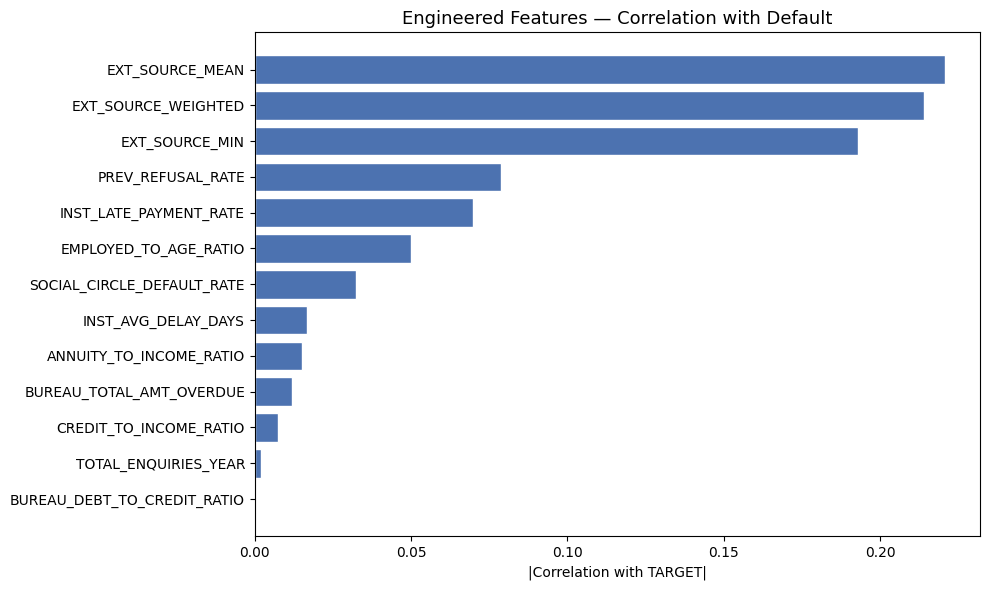

  Chart saved: engineered_feature_correlations.png

[STEP 4 COMPLETE]
  df_feat is ready: 307,507 rows × 282 cols


In [10]:
# ─────────────────────────────────────────────────────────────
# 4I. FEATURE ENGINEERING SUMMARY
# ─────────────────────────────────────────────────────────────

new_features = df_feat.shape[1] - starting_cols
print(f"""
=============================================================
STEP 4 SUMMARY — FEATURE ENGINEERING
=============================================================

  Starting columns  : {starting_cols}
  Final columns     : {df_feat.shape[1]}
  New features added: {new_features}

  Feature Groups:
  ├── Credit burden ratios      (5 features)
  ├── Age & employment          (3 features)
  ├── Documents & social        (2 features)
  ├── External credit scores    (5 features)
  ├── Credit enquiries          (2 features)
  ├── Bureau aggregations       (14 features)
  ├── Previous app aggregations (14 features)
  └── Installment behaviour     (8 features)

  Final dataset: {df_feat.shape[0]:,} rows × {df_feat.shape[1]} cols
=============================================================
""")

# ── Visualise new feature correlations with TARGET ───────────
new_feat_names = [
    "CREDIT_TO_INCOME_RATIO", "ANNUITY_TO_INCOME_RATIO",
    "EXT_SOURCE_MEAN", "EXT_SOURCE_WEIGHTED", "EXT_SOURCE_MIN",
    "EMPLOYED_TO_AGE_RATIO", "BUREAU_DEBT_TO_CREDIT_RATIO",
    "PREV_REFUSAL_RATE", "INST_LATE_PAYMENT_RATE",
    "INST_AVG_DELAY_DAYS", "BUREAU_TOTAL_AMT_OVERDUE",
    "SOCIAL_CIRCLE_DEFAULT_RATE", "TOTAL_ENQUIRIES_YEAR",
]
available_new = [c for c in new_feat_names if c in df_feat.columns]

corr_new = df_feat[available_new + ["TARGET"]].corr()["TARGET"].drop("TARGET")
corr_new = corr_new.abs().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(
    corr_new.index[::-1],
    corr_new.values[::-1],
    color="#4C72B0", edgecolor="white"
)
ax.set_xlabel("|Correlation with TARGET|")
ax.set_title("Engineered Features — Correlation with Default", fontsize=13)
plt.tight_layout()
plt.savefig("engineered_feature_correlations.png", dpi=150, bbox_inches="tight")
plt.show()
print("  Chart saved: engineered_feature_correlations.png")

print("\n[STEP 4 COMPLETE]")
print(f"  df_feat is ready: {df_feat.shape[0]:,} rows × {df_feat.shape[1]} cols")

In [11]:
df_feat.to_csv("D:\\home-credit-default-risk\\data\\processed\\application_train_features.csv", index=False)